In [1]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# 현재 최대 행/열 출력 제한 확인
print(f"현재 최대 행 수: {pd.get_option('display.max_rows')}")
print(f"현재 최대 열 수: {pd.get_option('display.max_columns')}")

# 제한 없이 출력하도록 설정 변경 (None은 제한 없음을 의미)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # 컬럼 너비 제한 해제

현재 최대 행 수: 100
현재 최대 열 수: None


In [3]:
# 데이터 로드
user_df = pd.read_csv('../../data/processed/01_user_profile_preprocessed_v2.csv')
event_df = pd.read_csv('../../data/processed/02_event_log_preprocessed_v2.csv')

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nuser_df: {user_df.shape}")
print(f"event_df: {event_df.shape}")


데이터 로드 완료!

user_df: (12500, 23)
event_df: (1757262, 17)


In [4]:
# ============================================================
# 컬럼명/날짜 파생컬럼 확인 및 보정
# ============================================================

# 날짜 컬럼 datetime 변환
event_df["event_time"] = pd.to_datetime(event_df["event_time"], errors="coerce")

# event_month 컬럼이 없으면 event_time에서 생성
if "event_month" not in event_df.columns:
    event_df["event_month"] = event_df["event_time"].dt.to_period("M").astype(str)

# event_weekday 컬럼이 없으면 생성
weekday_map = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

if "event_weekday" not in event_df.columns:
    event_df["event_weekday"] = event_df["event_time"].dt.dayofweek.map(weekday_map)

# event_hour 컬럼이 없으면 생성
if "event_hour" not in event_df.columns:
    event_df["event_hour"] = event_df["event_time"].dt.hour

# 로그 장애 기간 플래그가 없으면 생성
if "is_log_issue_period" not in event_df.columns:
    LOG_ISSUE_START = pd.Timestamp("2025-03-10")
    LOG_ISSUE_END = pd.Timestamp("2025-03-14 23:59:59")
    event_df["is_log_issue_period"] = event_df["event_time"].between(
        LOG_ISSUE_START,
        LOG_ISSUE_END
    )

print("event_df 주요 컬럼 확인:")
print([col for col in ["user_id", "event_time", "event_type", "event_month", "event_weekday", "event_hour", "is_log_issue_period"] if col in event_df.columns])


event_df 주요 컬럼 확인:
['user_id', 'event_time', 'event_type', 'event_month', 'event_weekday', 'event_hour', 'is_log_issue_period']


# D30 리텐션이 낮은 사람 중 누구를 챌린지로 전환시킬 수 있을까?
##### 이탈 가능성이 높은 ㄴ고객 중 개입 가능한 고객은 누굴까?

---
### 챌린지 미경험자 중 전환 ㄱ능성이 있는 유저 찾기

In [5]:
# 사전 챌린지 미경험자


u = user_df.copy()
e = event_df.copy()

# 날짜 타입 정리
u["signup_date"] = pd.to_datetime(u["signup_date"])
e["event_time"] = pd.to_datetime(e["event_time"])

# event_date가 없으면 생성
if "event_date" not in e.columns:
    e["event_date"] = e["event_time"].dt.normalize()
else:
    e["event_date"] = pd.to_datetime(e["event_date"])

# 로그 장애 기간 제외
if "is_log_issue_period" in e.columns:
    e_valid = e[~e["is_log_issue_period"].fillna(False)].copy()
else:
    e_valid = e.copy()

print("전체 이벤트 수:", len(e))
print("로그 장애 기간 제외 후 이벤트 수:", len(e_valid))

전체 이벤트 수: 1757262
로그 장애 기간 제외 후 이벤트 수: 1736400


In [6]:
# 챌린지 알림 수신 이벤트만 추출
challenge_receive = e_valid[
    (e_valid["notification_type"] == "챌린지_알림")
    & (e_valid["event_type"] == "알림수신")
].copy()

# 유저별 첫 챌린지 알림 수신 시점
first_challenge_receive = (
    challenge_receive
    .groupby("user_id")["event_time"]
    .min()
    .reset_index()
    .rename(columns={"event_time": "first_challenge_receive_time"})
)

print("첫 챌린지 알림 수신 유저 수:", first_challenge_receive["user_id"].nunique())

display(first_challenge_receive.head())

첫 챌린지 알림 수신 유저 수: 6205


,user_id,first_challenge_receive_time
0,U0000001,2025-01-31 12:12:00
1,U0000004,2025-02-25 10:53:00
2,U0000005,2025-02-24 20:51:00
3,U0000011,2025-03-09 15:43:00
4,U0000013,2025-01-11 18:29:00


In [7]:
# 첫 챌린지 알림 수신 유저를 user_df와 결합
base = u.merge(first_challenge_receive, on="user_id", how="inner")

# 기준 시점
base["index_time"] = base["first_challenge_receive_time"]

# 챌린지 행동 이벤트
challenge_actions = e_valid[
    e_valid["event_type"].isin(["챌린지_탐색", "챌린지참여"])
][["user_id", "event_time", "event_type"]].copy()

# 첫 챌린지 알림 수신 시점 붙이기
pre_challenge = challenge_actions.merge(
    base[["user_id", "index_time"]],
    on="user_id",
    how="inner"
)

# 첫 챌린지 알림 수신 이전 행동만 남기기
pre_challenge = pre_challenge[
    pre_challenge["event_time"] < pre_challenge["index_time"]
].copy()

# 유저별 사전 챌린지 행동 수
pre_challenge_count = (
    pre_challenge
    .groupby("user_id")
    .size()
    .reset_index(name="pre_challenge_action_count")
)

# base에 붙이기
base = base.merge(pre_challenge_count, on="user_id", how="left")

base["pre_challenge_action_count"] = (
    base["pre_challenge_action_count"]
    .fillna(0)
    .astype(int)
)

base["pre_has_any_challenge"] = base["pre_challenge_action_count"] > 0

display(base["pre_has_any_challenge"].value_counts())
display(base["pre_has_any_challenge"].value_counts(normalize=True))

pre_has_any_challenge
True     3336
False    2869
Name: count, dtype: int64

pre_has_any_challenge
True     0.537631
False    0.462369
Name: proportion, dtype: float64

In [8]:
newbie_base = base[base["pre_has_any_challenge"] == False].copy()

print("첫 챌린지 알림 수신 유저 수:", len(base))
print("사전 챌린지 미경험 유저 수:", len(newbie_base))
print("사전 챌린지 미경험 비율:", len(newbie_base) / len(base))

display(newbie_base[[
    "user_id",
    "signup_date",
    "first_challenge_receive_time",
    "pre_challenge_action_count",
    "pre_has_any_challenge"
]].head())

첫 챌린지 알림 수신 유저 수: 6205
사전 챌린지 미경험 유저 수: 2869
사전 챌린지 미경험 비율: 0.4623690572119259


,user_id,signup_date,first_challenge_receive_time,pre_challenge_action_count,pre_has_any_challenge
1,U0000004,2025-02-23,2025-02-25 10:53:00,0,False
6,U0000020,2025-02-07,2025-02-08 08:30:00,0,False
7,U0000023,2025-02-25,2025-02-26 19:10:00,0,False
9,U0000025,2025-05-11,2025-05-12 18:02:00,0,False
10,U0000027,2025-02-09,2025-02-11 11:25:00,0,False


In [9]:
print("전체 base:", base.shape)
print("newbie_base:", newbie_base.shape)

display(base["pre_has_any_challenge"].value_counts())

전체 base: (6205, 27)
newbie_base: (2869, 27)


pre_has_any_challenge
True     3336
False    2869
Name: count, dtype: int64

In [10]:
# 첫 챌린지 알림을 받은 뒤 7일 안에 챌린지참여 했는지 확인하는 라벨 생성

# 챌린지 참여 이벤트만 추출
challenge_join_logs = e_valid[
    e_valid["event_type"] == "챌린지참여"
][["user_id", "event_time"]].copy()

# newbie_base에 있는 유저의 index_time 붙이기
post_join = challenge_join_logs.merge(
    newbie_base[["user_id", "index_time"]],
    on="user_id",
    how="inner"
)

# 첫 챌린지 알림 수신 후 7일 내 챌린지 참여만 남기기
post_join_7d = post_join[
    (post_join["event_time"] >= post_join["index_time"])
    & (post_join["event_time"] <= post_join["index_time"] + pd.Timedelta(days=7))
].copy()

display(post_join_7d.head())
print("7일 내 챌린지 참여 로그 수:", len(post_join_7d))
print("7일 내 챌린지 참여 유저 수:", post_join_7d["user_id"].nunique())

,user_id,event_time,index_time
0,U0000004,2025-03-03 17:28:24,2025-02-25 10:53:00
3,U0000023,2025-03-05 16:19:54,2025-02-26 19:10:00
5,U0000027,2025-02-16 07:29:20,2025-02-11 11:25:00
23,U0000049,2025-01-26 07:34:50,2025-01-22 19:19:00
24,U0000049,2025-01-27 16:01:10,2025-01-22 19:19:00


7일 내 챌린지 참여 로그 수: 3979
7일 내 챌린지 참여 유저 수: 1226


In [11]:
# 유저별 7일 내 챌린지 참여 횟수
join_7d_count = (
    post_join_7d
    .groupby("user_id")
    .size()
    .reset_index(name="challenge_join_7d_count")
)

# newbie_base에 붙이기
newbie_base = newbie_base.merge(
    join_7d_count,
    on="user_id",
    how="left"
)

newbie_base["challenge_join_7d_count"] = (
    newbie_base["challenge_join_7d_count"]
    .fillna(0)
    .astype(int)
)

# 전환 여부 라벨
newbie_base["converted_join_7d"] = newbie_base["challenge_join_7d_count"] > 0

display(newbie_base[[
    "user_id",
    "index_time",
    "challenge_join_7d_count",
    "converted_join_7d"
]].head())

,user_id,index_time,challenge_join_7d_count,converted_join_7d
0,U0000004,2025-02-25 10:53:00,1,True
1,U0000020,2025-02-08 08:30:00,0,False
2,U0000023,2025-02-26 19:10:00,1,True
3,U0000025,2025-05-12 18:02:00,0,False
4,U0000027,2025-02-11 11:25:00,1,True


In [13]:
conversion_summary = (
    newbie_base["converted_join_7d"]
    .value_counts()
    .rename_axis("converted_join_7d")
    .reset_index(name="user_count")
)

conversion_summary["ratio"] = conversion_summary["user_count"] / len(newbie_base)

display(conversion_summary)

,converted_join_7d,user_count,ratio
0,False,1643,0.572673
1,True,1226,0.427327


In [14]:
print("newbie_base:", newbie_base.shape)
display(newbie_base["converted_join_7d"].value_counts())
display(newbie_base["converted_join_7d"].value_counts(normalize=True))

newbie_base: (2869, 29)


converted_join_7d
False    1643
True     1226
Name: count, dtype: int64

converted_join_7d
False    0.572673
True     0.427327
Name: proportion, dtype: float64

사전 챌린지 미경험자 중 첫 챌린지 알림 수신 후
- 7일 내 챌린지 전환 안 함 : 57.3%
- 7일 내 챌린지 전환함 : 42.7%  
-> 전환된 사람은 미전환 그룹과 비교했을 때 첫 챌린지 알림 수신 이전 어떻게 달랐는가?    
### -> 초기 행동 피처 만들어서 비교
> 첫 챌린지 알림 수신 이후 행동은 피처에 넣지 않는다


- early_app_event_count	초기 앱 내 행동 수
- early_app_launch_count	초기 앱실행 수
- early_active_days	초기 활성일 수
- early_session_count	초기 세션 수
- early_sleep_record_count	초기 수면기록 수
- early_exercise_record_count	초기 운동기록 수
- early_diet_record_count	초기 식단기록 수
- early_mindfulness_count	초기 마음챙김 수
- early_record_event_count	기록 기능 전체 사용 수
- early_notification_open_count	초기 알림오픈 수
- early_remind_open_count	초기 리마인드 알림 오픈 수
- early_ad_open_count	초기 광고성 알림 오픈 수

In [15]:
# 전환 전 초기 행동 피처 생성

# 분석용 복사
features_base = newbie_base.copy()

# 날짜 타입 확인
features_base["signup_date"] = pd.to_datetime(features_base["signup_date"])
features_base["index_time"] = pd.to_datetime(features_base["index_time"])

# 가입 후 7일 시점
features_base["signup_plus_7d"] = features_base["signup_date"] + pd.Timedelta(days=7)

# 피처 시작/종료 시점
features_base["feature_start"] = features_base["signup_date"]
features_base["feature_end"] = features_base[["signup_plus_7d", "index_time"]].min(axis=1)

# 피처 관찰 가능 시간
features_base["feature_window_hours"] = (
    features_base["feature_end"] - features_base["feature_start"]
).dt.total_seconds() / 3600

features_base["feature_window_days"] = features_base["feature_window_hours"] / 24

# 피처 윈도우가 0 이하인 유저는 제외
features_base = features_base[features_base["feature_window_hours"] > 0].copy()

print("피처 생성 대상 유저 수:", len(features_base))
display(features_base["feature_window_days"].describe())

피처 생성 대상 유저 수: 2869


count    2869.000000
mean        1.782155
std         1.701329
min         0.332998
25%         0.558333
50%         0.863194
75%         2.542361
max         7.000000
Name: feature_window_days, dtype: float64

In [17]:
# 피처 윈도우 정보 붙이기
window_event = e_valid.merge(
    features_base[["user_id", "feature_start", "feature_end"]],
    on="user_id",
    how="inner"
)

# 가입일 ~ 첫 챌린지 알림 수신 전 사이 이벤트만 남기기
window_event = window_event[
    (window_event["event_time"] >= window_event["feature_start"])
    & (window_event["event_time"] < window_event["feature_end"])
].copy()

# 앱 내 행동 이벤트 여부
# 알림수신/알림오픈은 앱 행동에서 제외
window_event["is_app_event"] = (
    window_event["event_type"].notna()
    & ~window_event["event_type"].isin(["알림수신", "알림오픈"])
)

# 앱 행동 이벤트
app_event = window_event[window_event["is_app_event"]].copy()

# 알림 이벤트
noti_event = window_event[
    window_event["event_type"].isin(["알림수신", "알림오픈"])
].copy()

print("window_event:", window_event.shape)
print("app_event:", app_event.shape)
print("noti_event:", noti_event.shape)

display(app_event["event_type"].value_counts(dropna=False))
display(noti_event["event_type"].value_counts(dropna=False))

window_event: (26362, 20)
app_event: (22401, 20)
noti_event: (3574, 20)


event_type
앱실행       12154
수면기록       4008
마음챙김       2157
운동기록       1941
식단기록       1686
온보딩_완료      455
Name: count, dtype: int64

event_type
알림수신    3200
알림오픈     374
Name: count, dtype: int64

In [18]:
# 기본 앱 행동 집계
app_basic = (
    app_event
    .groupby("user_id")
    .agg(
        early_app_event_count=("event_type", "size"),
        early_active_days=("event_date", "nunique"),
        early_session_count=("session_id", "nunique")
    )
    .reset_index()
)

# 이벤트 타입별 횟수
event_type_count = (
    app_event
    .pivot_table(
        index="user_id",
        columns="event_type",
        values="event_time",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

# 컬럼명 변경
event_type_count = event_type_count.rename(columns={
    "앱실행": "early_app_launch_count",
    "수면기록": "early_sleep_record_count",
    "운동기록": "early_exercise_record_count",
    "식단기록": "early_diet_record_count",
    "마음챙김": "early_mindfulness_count",
    "온보딩_완료": "early_onboarding_complete_count"
})

# 필요한 컬럼이 없는 경우 0으로 생성
needed_cols = [
    "early_app_launch_count",
    "early_sleep_record_count",
    "early_exercise_record_count",
    "early_diet_record_count",
    "early_mindfulness_count",
    "early_onboarding_complete_count"
]

for col in needed_cols:
    if col not in event_type_count.columns:
        event_type_count[col] = 0

In [ ]:
# 전체 알림 수신/오픈 횟수
noti_basic = (
    noti_event
    .pivot_table(
        index="user_id",
        columns="event_type",
        values="event_time",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
    .rename(columns={
        "알림수신": "early_notification_receive_count",
        "알림오픈": "early_notification_open_count"
    })
)

for col in ["early_notification_receive_count", "early_notification_open_count"]:
    if col not in noti_basic.columns:
        noti_basic[col] = 0


# 알림 유형별 오픈 횟수
noti_open_by_type = noti_event[
    noti_event["event_type"] == "알림오픈"
].copy()

noti_open_type_count = (
    noti_open_by_type
    .pivot_table(
        index="user_id",
        columns="notification_type",
        values="event_time",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
    .rename(columns={
        "리마인드": "early_remind_open_count",
        "광고성": "early_ad_open_count",
        "챌린지_알림": "early_challenge_noti_open_count"
    })
)

for col in [
    "early_remind_open_count",
    "early_ad_open_count",
    "early_challenge_noti_open_count"   # 리마인드나 광고성 알림에 이미 반응했는지
]:
    if col not in noti_open_type_count.columns:
        noti_open_type_count[col] = 0

In [20]:
# 기본 유저 정보 + 전환 라벨
feature_df = features_base.copy()

# 앱 행동 피처 merge
feature_df = feature_df.merge(app_basic, on="user_id", how="left")
feature_df = feature_df.merge(
    event_type_count[["user_id"] + needed_cols],
    on="user_id",
    how="left"
)

# 알림 피처 merge
feature_df = feature_df.merge(
    noti_basic[[
        "user_id",
        "early_notification_receive_count",
        "early_notification_open_count"
    ]],
    on="user_id",
    how="left"
)

feature_df = feature_df.merge(
    noti_open_type_count[[
        "user_id",
        "early_remind_open_count",
        "early_ad_open_count",
        "early_challenge_noti_open_count"
    ]],
    on="user_id",
    how="left"
)

# early 관련 count 컬럼 결측치 0 처리
early_count_cols = [
    col for col in feature_df.columns
    if col.startswith("early_") and col.endswith("_count")
]

feature_df[early_count_cols] = feature_df[early_count_cols].fillna(0).astype(int)

# 기본 집계 결측치 0 처리
for col in ["early_app_event_count", "early_active_days", "early_session_count"]:
    if col in feature_df.columns:
        feature_df[col] = feature_df[col].fillna(0).astype(int)

# 기록 기능 전체 사용 수
record_cols = [
    "early_sleep_record_count",
    "early_exercise_record_count",
    "early_diet_record_count",
    "early_mindfulness_count"
]

feature_df["early_record_event_count"] = feature_df[record_cols].sum(axis=1)

# 여부형 변수
feature_df["early_has_any_record"] = feature_df["early_record_event_count"] > 0
feature_df["early_has_sleep_record"] = feature_df["early_sleep_record_count"] > 0
feature_df["early_has_exercise_record"] = feature_df["early_exercise_record_count"] > 0
feature_df["early_has_diet_record"] = feature_df["early_diet_record_count"] > 0
feature_df["early_has_mindfulness"] = feature_df["early_mindfulness_count"] > 0
feature_df["early_has_notification_open"] = feature_df["early_notification_open_count"] > 0
feature_df["early_has_remind_open"] = feature_df["early_remind_open_count"] > 0
feature_df["early_has_ad_open"] = feature_df["early_ad_open_count"] > 0

print("feature_df shape:", feature_df.shape)

display(feature_df[[
    "user_id",
    "converted_join_7d",
    "feature_window_days",
    "early_app_event_count",
    "early_app_launch_count",
    "early_active_days",
    "early_session_count",
    "early_record_event_count",
    "early_notification_open_count",
    "early_remind_open_count",
    "early_ad_open_count"
]].head())

feature_df shape: (2869, 57)


,user_id,converted_join_7d,feature_window_days,early_app_event_count,early_app_launch_count,early_active_days,early_session_count,early_record_event_count,early_notification_open_count,early_remind_open_count,early_ad_open_count
0,U0000004,True,2.453472,9,4,2,4,5,0,0,0
1,U0000020,False,1.354167,8,4,2,4,3,0,0,0
2,U0000023,True,1.798611,14,6,2,6,8,0,0,0
3,U0000025,False,1.751389,14,8,2,8,5,1,1,0
4,U0000027,True,2.475694,23,9,3,9,14,0,0,0


In [21]:
print("feature_df:", feature_df.shape)

display(feature_df["converted_join_7d"].value_counts())

display(feature_df[[
    "feature_window_days",
    "early_app_event_count",
    "early_app_launch_count",
    "early_active_days",
    "early_session_count",
    "early_record_event_count",
    "early_notification_receive_count",
    "early_notification_open_count",
    "early_remind_open_count",
    "early_ad_open_count"
]].describe())

feature_df: (2869, 57)


converted_join_7d
False    1643
True     1226
Name: count, dtype: int64

,feature_window_days,early_app_event_count,early_app_launch_count,early_active_days,early_session_count,early_record_event_count,early_notification_receive_count,early_notification_open_count,early_remind_open_count,early_ad_open_count
count,2869.000000,2869.000000,2869.000000,2869.000000,2869.000000,2869.000000,2869.000000,2869.000000,2869.000000,2869.000000
mean,1.782155,7.807947,4.236319,1.752527,4.249216,3.413036,1.115371,0.130359,0.116068,0.012548
std,1.701329,8.940435,4.778343,1.672684,4.794334,4.328216,1.633080,0.379590,0.359349,0.114421
min,0.332998,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.558333,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.863194,5.000000,3.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000
75%,2.542361,11.000000,6.000000,2.000000,6.000000,5.000000,2.000000,0.000000,0.000000,0.000000
max,7.000000,64.000000,35.000000,7.000000,35.000000,37.000000,7.000000,3.000000,3.000000,2.000000


feature_window_days 평균 1.78   
-> 많은 유저가 가입 후 얼마 안 돼서 첫 챌린지 알림을 받았음 
- early_app_event_cout가 높다 =/= 활동성이 높다
    - 피처 관찰기간이 긴 유저가 더 많은 이벤트를 가질 수 있기 때문  


In [ ]:
# 전환 유저 vs 미전환 유저 비교
## 사전 챌린지 미 경험자 중 7일 내 챌린지 참여로 전환된 유저는 
## 미전환 유저와 어떤 초기 행동 특성이 다른가

# 연속형 / 카운트 변수 비교 함수
def compare_numeric(df, col, target="converted_join_7d"):
    temp = df[[col, target]].dropna().copy()
    
    converted = temp[temp[target] == True][col]
    not_converted = temp[temp[target] == False][col]
    
    n1 = len(converted)
    n0 = len(not_converted)
    
    if n1 == 0 or n0 == 0:
        return None
    
    u_stat, p_value = mannwhitneyu(
        converted,
        not_converted,
        alternative="two-sided"
    )
    
    # rank-biserial correlation
    # 양수면 전환 유저 쪽 값이 더 큰 경향
    rank_biserial = (2 * u_stat / (n1 * n0)) - 1
    
    return {
        "feature": col,
        "converted_mean": converted.mean(),
        "not_converted_mean": not_converted.mean(),
        "converted_median": converted.median(),
        "not_converted_median": not_converted.median(),
        "mean_diff": converted.mean() - not_converted.mean(),
        "p_value": p_value,
        "rank_biserial": rank_biserial,
        "abs_effect": abs(rank_biserial)
    }

In [23]:
numeric_cols = [
    "feature_window_days",
    "early_app_event_count",
    "early_app_launch_count",
    "early_active_days",
    "early_session_count",
    "early_record_event_count",
    "early_sleep_record_count",
    "early_exercise_record_count",
    "early_diet_record_count",
    "early_mindfulness_count",
    "early_notification_receive_count",
    "early_notification_open_count",
    "early_remind_open_count",
    "early_ad_open_count"
]

numeric_cols = [col for col in numeric_cols if col in feature_df.columns]

numeric_results = []

for col in numeric_cols:
    result = compare_numeric(feature_df, col)
    if result is not None:
        numeric_results.append(result)

numeric_result_df = pd.DataFrame(numeric_results)

numeric_result_df = numeric_result_df.sort_values(
    "abs_effect",
    ascending=False
)

display(numeric_result_df)

,feature,converted_mean,not_converted_mean,converted_median,not_converted_median,mean_diff,p_value,rank_biserial,abs_effect
3,early_active_days,1.528548,1.919659,1.000000,1.000000,-0.391111,1.903862e-22,-0.203622,0.203622
0,feature_window_days,1.634880,1.892052,0.714236,1.464583,-0.257172,6.464758e-20,-0.199105,0.199105
1,early_app_event_count,7.269168,8.209982,3.000000,6.000000,-0.940814,4.314052e-18,-0.188112,0.188112
2,early_app_launch_count,3.952692,4.447961,2.000000,3.000000,-0.495269,3.921423e-18,-0.187683,0.187683
4,early_session_count,3.960033,4.465003,2.000000,3.000000,-0.504970,4.303075e-18,-0.187460,0.187460
5,early_record_event_count,3.198206,3.573341,1.000000,2.000000,-0.375136,7.861843e-14,-0.160271,0.160271
10,early_notification_receive_count,0.961664,1.230067,0.000000,1.000000,-0.268403,2.373732e-14,-0.152926,0.152926
6,early_sleep_record_count,1.262643,1.497261,0.000000,1.000000,-0.234618,1.725181e-10,-0.131594,0.131594
9,early_mindfulness_count,0.699021,0.791236,0.000000,0.000000,-0.092214,1.284604e-06,-0.094163,0.094163
8,early_diet_record_count,0.538336,0.624467,0.000000,0.000000,-0.086131,8.700467e-07,-0.091589,0.091589


In [ ]:
# 여부형 피처 생성

feature_df["early_has_app_launch"] = feature_df["early_app_launch_count"] > 0
feature_df["early_has_any_record"] = feature_df["early_record_event_count"] > 0
feature_df["early_has_sleep_record"] = feature_df["early_sleep_record_count"] > 0
feature_df["early_has_exercise_record"] = feature_df["early_exercise_record_count"] > 0
feature_df["early_has_diet_record"] = feature_df["early_diet_record_count"] > 0
feature_df["early_has_mindfulness"] = feature_df["early_mindfulness_count"] > 0
feature_df["early_has_notification_open"] = feature_df["early_notification_open_count"] > 0
feature_df["early_has_remind_open"] = feature_df["early_remind_open_count"] > 0
feature_df["early_has_ad_open"] = feature_df["early_ad_open_count"] > 0

In [33]:
from scipy.stats import chi2_contingency


def compare_binary(df, col, target="converted_join_7d"):
    temp = df[[col, target]].dropna().copy()
    
    # bool을 0/1로 변환
    temp[col] = temp[col].astype(bool).astype(int)
    temp[target] = temp[target].astype(bool).astype(int)
    
    # 0: False, 1: True
    table = pd.crosstab(temp[col], temp[target])
    
    # 행/열을 0, 1로 강제 정렬
    table = table.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    
    n_false = table.loc[0].sum()
    n_true = table.loc[1].sum()
    
    converted_false = table.loc[0, 1]
    converted_true = table.loc[1, 1]
    
    # 한쪽 그룹이 없으면 비교 불가
    if n_false == 0 or n_true == 0:
        return {
            "feature": col,
            "n_false": n_false,
            "n_true": n_true,
            "conversion_rate_false": np.nan,
            "conversion_rate_true": np.nan,
            "risk_diff": np.nan,
            "risk_ratio": np.nan,
            "p_value": np.nan,
            "cramers_v": np.nan,
            "abs_effect": np.nan,
            "note": "한쪽 값만 존재해서 비교 불가"
        }
    
    rate_false = converted_false / n_false
    rate_true = converted_true / n_true
    
    risk_diff = rate_true - rate_false
    risk_ratio = rate_true / rate_false if rate_false > 0 else np.nan
    
    chi2, p_value, _, _ = chi2_contingency(table, correction=False)
    
    n = table.values.sum()
    cramers_v = np.sqrt(chi2 / n) if n > 0 else np.nan
    
    return {
        "feature": col,
        "n_false": n_false,
        "n_true": n_true,
        "conversion_rate_false": rate_false,
        "conversion_rate_true": rate_true,
        "risk_diff": risk_diff,
        "risk_ratio": risk_ratio,
        "p_value": p_value,
        "cramers_v": cramers_v,
        "abs_effect": abs(cramers_v),
        "note": ""
    }

In [34]:
test_result = compare_binary(feature_df, "early_has_any_record")

print(type(test_result))
print(test_result)

<class 'dict'>
{'feature': 'early_has_any_record', 'n_false': np.int64(829), 'n_true': np.int64(2040), 'conversion_rate_false': np.float64(0.5621230398069964), 'conversion_rate_true': np.float64(0.37254901960784315), 'risk_diff': np.float64(-0.18957402019915326), 'risk_ratio': np.float64(0.6627535134225364), 'p_value': np.float64(1.3518483716979787e-20), 'cramers_v': np.float64(0.17370293323399114), 'abs_effect': np.float64(0.17370293323399114), 'note': ''}


In [35]:
# 여부형 피처 비교

binary_cols = [
    "early_has_app_launch",
    "early_has_any_record",
    "early_has_sleep_record",
    "early_has_exercise_record",
    "early_has_diet_record",
    "early_has_mindfulness",
    "early_has_notification_open",
    "early_has_remind_open",
    "early_has_ad_open",
    "is_onboarding_completed"
]

binary_cols = [col for col in binary_cols if col in feature_df.columns]

binary_results = []

for col in binary_cols:
    result = compare_binary(feature_df, col)
    binary_results.append(result)

binary_result_df = pd.DataFrame(binary_results)

binary_result_df = binary_result_df.sort_values(
    "abs_effect",
    ascending=False
)

display(binary_result_df)

,feature,n_false,n_true,conversion_rate_false,conversion_rate_true,risk_diff,risk_ratio,p_value,cramers_v,abs_effect,note
0,early_has_app_launch,541,2328,0.639556,0.378007,-0.261550,0.591045,1.611523e-28,0.206814,0.206814,
9,is_onboarding_completed,1953,916,0.365591,0.558952,0.193361,1.528898,1.664821e-22,0.182223,0.182223,
1,early_has_any_record,829,2040,0.562123,0.372549,-0.189574,0.662754,1.351848e-20,0.173703,0.173703,
2,early_has_sleep_record,1282,1587,0.499220,0.369250,-0.129970,0.739654,2.625751e-12,0.130620,0.130620,
4,early_has_diet_record,1828,1041,0.466083,0.359270,-0.106813,0.770828,2.684927e-08,0.103818,0.103818,
5,early_has_mindfulness,1646,1223,0.471446,0.367948,-0.103498,0.780466,2.991251e-08,0.103466,0.103466,
3,early_has_exercise_record,1752,1117,0.446347,0.397493,-0.048854,0.890548,9.901624e-03,0.048153,0.048153,
7,early_has_remind_open,2573,296,0.432180,0.385135,-0.047045,0.891145,1.212695e-01,0.028928,0.028928,
6,early_has_notification_open,2537,332,0.432400,0.388554,-0.043846,0.898598,1.288459e-01,0.028353,0.028353,
8,early_has_ad_open,2834,35,0.427311,0.428571,0.001260,1.002949,9.880491e-01,0.000280,0.000280,


### 수치형 / 여부형 피처 결과 정리
- 전환 유저는 오히려 초기 앱 행동량이 적다
    - feature_window_days	전환 유저 쪽이 더 짧거나 낮은 경향
    - early_app_event_count	전환 유저가 더 낮음
    - early_app_launch_count	전환 유저가 더 낮음
    - early_session_count	전환 유저가 더 낮음
    - early_active_days	전환 유저가 더 낮음
    - early_record_event_count	전환 유저가 더 낮음
- 여부형 결과와 수치형 결과가 같은 방향을 가리킴
    - 앱실행 경험 있음	오히려 낮음
    - 기록 경험 있음	오히려 낮음
    - 수면기록 있음	오히려 낮음
    - 식단기록 있음	오히려 낮음
    - 마음챙김 있음	오히려 낮음
> -> 챌린지 알림은 이미 기록 루틴을 만들고 있는 유저보다    
>    아직 앱 내 행동이 많지 않은 유저에게 새로운 진입 경로로 작동했을 가능성

- 다만, feature_window_days 전체 평균이 1.78일, 중앙값이 0.86으로   
많은 유저가 가입 후 매우 이른 시점에 첫 챌린지 알림을 받음
- -> 첫 챌린지 알림 수신 시점이 매우 이른 유저가 많기 때문에    
활동량이 더 적은 유저가 더 전환 잘되는 것처럼 보일 수 있음
- -> 관찰기간 차이를 통제해서 추가 조사 필요

- 명확한 양의 방향 : 온보딩 완료
    - 19.3%p 차이. 효과크기 0.182
- -> 챌린지 미경험자 중 온보딩을 완료한 유저는 챌린지 참여 전환 가능성이 높ㄷ

---
### 관찰기간 차이 확인
##### 전환율 차이가 진짜 행동 특성 때문인지 알림 수신 시점 차이 때문인지 확인


In [ ]:
# 전환 여부별 관찰기간과 초기 행동 비교

check_cols = [
    "feature_window_days",
    "early_app_event_count",
    "early_app_launch_count",
    "early_active_days",
    "early_session_count",
    "early_record_event_count",
    "early_notification_receive_count",
    "early_notification_open_count"
]

feature_df.groupby("converted_join_7d")[check_cols].agg(
    ["mean", "median", "count"]
)

feature_window_days                 early_app_event_count  \
                                 mean    median count                  mean   
converted_join_7d                                                             
False                        1.892052  1.464583  1643              8.209982   
True                         1.634880  0.714236  1226              7.269168   

                               early_app_launch_count               \
                  median count                   mean median count   
converted_join_7d                                                    
False                6.0  1643               4.447961    3.0  1643   
True                 3.0  1226               3.952692    2.0  1226   

                  early_active_days              early_session_count         \
                               mean median count                mean median   
converted_join_7d                                                             
False                      1.919659    1.0  1643            4.465003    3.0   
True                       1.528548    1.0  1226            3.960033    2.0   

                        early_record_event_count               \
                  count                     mean median count   
converted_join_7d                                               
False              1643                 3.573341    2.0  1643   
True               1226                 3.198206    1.0  1226   

                  early_notification_receive_count               \
                                              mean median count   
converted_join_7d                                                 
False                                     1.230067    1.0  1643   
True                                      0.961664    0.0  1226   

                  early_notification_open_count               
                                           mean median count  
converted_join_7d                                             
False                                  0.139988    0.0  1643  
True                                   0.117455    0.0  1226

In [37]:
# 첫 챌린지 알림을 며칠차에 받았는지
feature_df["days_to_first_challenge_receive"] = (
    pd.to_datetime(feature_df["first_challenge_receive_time"])
    - pd.to_datetime(feature_df["signup_date"])
).dt.total_seconds() / 86400

feature_df.groupby("converted_join_7d")[
    "days_to_first_challenge_receive"
].agg(["mean", "median", "min", "max", "count"])

,mean,median,min,max,count
converted_join_7d,,,,,
False,1.978126,1.464583,0.333333,29.641667,1643
True,1.752216,0.714236,0.332998,22.633333,1226


In [38]:
# 온보딩 완료 여부별 관찰기간 확ㅇ
onboarding_summary = (
    feature_df
    .groupby("is_onboarding_completed")
    .agg(
        user_count=("user_id", "nunique"),
        conversion_rate=("converted_join_7d", "mean"),
        avg_feature_window_days=("feature_window_days", "mean"),
        median_feature_window_days=("feature_window_days", "median"),
        avg_days_to_first_challenge_receive=("days_to_first_challenge_receive", "mean"),
        median_days_to_first_challenge_receive=("days_to_first_challenge_receive", "median")
    )
    .reset_index()
)

display(onboarding_summary)

,is_onboarding_completed,user_count,conversion_rate,avg_feature_window_days,median_feature_window_days,avg_days_to_first_challenge_receive,median_days_to_first_challenge_receive
0,False,1953,0.365591,1.915640,1.432639,2.021761,1.432639
1,True,916,0.558952,1.497553,0.709722,1.582726,0.709722


- 전환 유저는 첫 챌린지 알림을 조금 더 빨리 받음
    - 평균 : 1.75 / 1.98
    - 중앙값 : 0.71 / 1.46
    - -> 전환 이전 행동이 더 적었던 이유 : 알림을 일찍 수신해서
- 온보딩 완료 완료 유저도 첫 챌린지 알림 수신이 빠른 편이었음
    - 중앙값 : 0.71 / 1.43
### 현재 가설
##### 챌린지 알림을 빨리 보내면 전환이 오른다
##### 그렇다면 첫 챌린지 알림수신 시점이 비슷한 유저끼리 비교해도 온보딩 완료자의 전환율이 높을까?

In [39]:
# 첫 챌린지 알림 수신 시점 구간 생성
feature_df["receive_timing_group"] = pd.cut(
    feature_df["days_to_first_challenge_receive"],
    bins=[-np.inf, 1, 3, 7, np.inf],
    labels=["1일 이내", "1~3일", "3~7일", "7일 이후"]
)

display(feature_df["receive_timing_group"].value_counts(dropna=False))

receive_timing_group
1일 이내    1457
1~3일      902
3~7일      431
7일 이후      79
Name: count, dtype: int64

In [40]:
# 수신 시점 구간별 전환율 확인
timing_summary = (
    feature_df
    .groupby("receive_timing_group", observed=False)
    .agg(
        user_count=("user_id", "nunique"),
        conversion_rate=("converted_join_7d", "mean"),
        onboarding_rate=("is_onboarding_completed", "mean"),
        avg_app_event_count=("early_app_event_count", "mean"),
        avg_record_event_count=("early_record_event_count", "mean")
    )
    .reset_index()
)

display(timing_summary)

,receive_timing_group,user_count,conversion_rate,onboarding_rate,avg_app_event_count,avg_record_event_count
0,1일 이내,1457,0.503089,0.390528,2.354839,1.013040
1,1~3일,902,0.317073,0.243902,9.501109,4.125277
2,3~7일,431,0.380510,0.248260,18.802784,8.271462
3,7일 이후,79,0.544304,0.253165,29.063291,13.037975


In [41]:
# 수신 시점 구간 안에서 온보딩 완료 여부 비교
timing_onboarding_summary = (
    feature_df
    .groupby(["receive_timing_group", "is_onboarding_completed"], observed=False)
    .agg(
        user_count=("user_id", "nunique"),
        conversion_rate=("converted_join_7d", "mean"),
        avg_feature_window_days=("feature_window_days", "mean"),
        median_feature_window_days=("feature_window_days", "median")
    )
    .reset_index()
)

display(timing_onboarding_summary)

,receive_timing_group,is_onboarding_completed,user_count,conversion_rate,avg_feature_window_days,median_feature_window_days
0,1일 이내,False,888,0.376126,0.585705,0.571528
1,1일 이내,True,569,0.701230,0.556505,0.546528
2,1~3일,False,682,0.326979,1.968572,1.755903
3,1~3일,True,220,0.286364,1.955787,1.740278
4,3~7일,False,324,0.388889,4.523372,4.427083
5,3~7일,True,107,0.355140,4.531162,4.422222
6,7일 이후,False,59,0.525424,7.000000,7.000000
7,7일 이후,True,20,0.600000,7.000000,7.000000


- 첫 챌린지 알림일 & 전환율
    - 1일 이내	1,457명	50.3%
    - 1~3일	    902명	31.7%
    - 3~7일	    431명	38.1%
    - 7일 이후	79명	54.4%
- 온보딩 완료 효과는 1일 이내에서만 강하게 나타남
    - 미완료	888명	37.6%
    - 완료	    569명	70.1%
- -> 가입후 1일 이내에 챌린지 알림을 받은 유저 중   
온보딩 완료자는 챌린지 참여 전환율이 70.1%로 매우 높다
- -> 가입 직후 + 온보딩 완료


In [42]:
# 1일 이내 수신자만 따로 검정
early_1d = feature_df[
    feature_df["receive_timing_group"] == "1일 이내"
].copy()

print("1일 이내 수신자 수:", len(early_1d))

result_1d_onboarding = compare_binary(
    early_1d,
    col="is_onboarding_completed",
    target="converted_join_7d"
)

display(pd.DataFrame([result_1d_onboarding]))

1일 이내 수신자 수: 1457


,feature,n_false,n_true,conversion_rate_false,conversion_rate_true,risk_diff,risk_ratio,p_value,cramers_v,abs_effect,note
0,is_onboarding_completed,888,569,0.376126,0.70123,0.325104,1.864349,9.511522e-34,0.317222,0.317222,


1일 이내 챌린지 알림 수신자 중 온보딩 완료 vs 미완료
    - risk diff : 32.5%p
    - risk ratio : 약 1.86배
    - cramer's v : 0.317

---
### 세그먼트별 D30 확인
- 유저 수
- 7일 내 챌린지 참여 전환율
- D30 리텐션

In [44]:
# d30 리텐션 컬럼 생성

# user_df, event_df 기준으로 다시 복사
u_d30 = user_df.copy()
e_d30 = event_df.copy()

u_d30["signup_date"] = pd.to_datetime(u_d30["signup_date"]).dt.normalize()
e_d30["event_time"] = pd.to_datetime(e_d30["event_time"])

In [45]:
# 로그 장애 기간 제외

if "is_log_issue_period" in e_d30.columns:
    e_d30_valid = e_d30[~e_d30["is_log_issue_period"].fillna(False)].copy()
else:
    e_d30_valid = e_d30.copy()

print("전체 이벤트 수:", len(e_d30))
print("로그 장애 기간 제외 후 이벤트 수:", len(e_d30_valid))

전체 이벤트 수: 1757262
로그 장애 기간 제외 후 이벤트 수: 1736400


In [46]:
# d30 관측 여부

# 로그 종료일
log_end_date = e_d30_valid["event_time"].max().normalize()

# 가입 후 30일째 날짜
u_d30["d30_date"] = u_d30["signup_date"] + pd.Timedelta(days=30)

# D30 관측 가능 여부
u_d30["d30_observable"] = u_d30["d30_date"] <= log_end_date

print("로그 종료일:", log_end_date)
display(u_d30["d30_observable"].value_counts())
display(u_d30["d30_observable"].value_counts(normalize=True))

로그 종료일: 2025-06-30 00:00:00


d30_observable
True    12500
Name: count, dtype: int64

d30_observable
True    1.0
Name: proportion, dtype: float64

In [47]:
# d30 활성 행동 여부 생성

# 알림 이벤트는 활성 행동에서 제외
notification_events = ["알림수신", "알림오픈"]

e_d30_valid["is_active_app_event"] = (
    e_d30_valid["event_type"].notna()
    & ~e_d30_valid["event_type"].isin(notification_events)
)

# 활성 행동 이벤트만 사용
active_events = e_d30_valid[e_d30_valid["is_active_app_event"]].copy()

# 유저별 d30_date 붙이기
d30_events = active_events.merge(
    u_d30[["user_id", "d30_date"]],
    on="user_id",
    how="inner"
)

# 가입 후 정확히 30일째 발생한 활성 행동
d30_events = d30_events[
    d30_events["event_date"] == d30_events["d30_date"]
].copy()

# 유저별 D30 활성 행동 수
d30_event_count = (
    d30_events
    .groupby("user_id")
    .size()
    .reset_index(name="d30_active_event_count")
)

# user_df에 붙이기
u_d30 = u_d30.merge(
    d30_event_count,
    on="user_id",
    how="left"
)

u_d30["d30_active_event_count"] = (
    u_d30["d30_active_event_count"]
    .fillna(0)
    .astype(int)
)

# 최종 D30 리텐션
u_d30["d30_retained"] = (
    u_d30["d30_observable"]
    & (u_d30["d30_active_event_count"] > 0)
)

display(u_d30[["d30_observable", "d30_retained"]].value_counts())

d30_observable  d30_retained
True            False           9551
                True            2949
Name: count, dtype: int64

In [48]:
# 혹시 기존에 같은 컬럼이 있다면 제거
drop_cols = [
    "d30_date",
    "d30_observable",
    "d30_active_event_count",
    "d30_retained"
]

feature_df = feature_df.drop(
    columns=[col for col in drop_cols if col in feature_df.columns],
    errors="ignore"
)

# D30 컬럼 붙이기
feature_df = feature_df.merge(
    u_d30[[
        "user_id",
        "d30_date",
        "d30_observable",
        "d30_active_event_count",
        "d30_retained"
    ]],
    on="user_id",
    how="left"
)

print("feature_df shape:", feature_df.shape)

display(feature_df[[
    "user_id",
    "converted_join_7d",
    "d30_observable",
    "d30_active_event_count",
    "d30_retained"
]].head())

feature_df shape: (2869, 64)


,user_id,converted_join_7d,d30_observable,d30_active_event_count,d30_retained
0,U0000004,True,True,3,True
1,U0000020,False,True,0,False
2,U0000023,True,True,2,True
3,U0000025,False,True,0,False
4,U0000027,True,True,0,False


In [49]:
print("D30 관측 가능 유저 수")
display(feature_df["d30_observable"].value_counts())

print("D30 리텐션")
display(feature_df["d30_retained"].value_counts())

print("D30 관측 가능 유저 기준 리텐션율")
display(
    feature_df[feature_df["d30_observable"] == True]["d30_retained"]
    .value_counts(normalize=True)
)

D30 관측 가능 유저 수


d30_observable
True    2869
Name: count, dtype: int64

D30 리텐션


d30_retained
False    2282
True      587
Name: count, dtype: int64

D30 관측 가능 유저 기준 리텐션율


d30_retained
False    0.795399
True     0.204601
Name: proportion, dtype: float64

### 가입후 1일 이내 + 온보딩 완료 + 챌린지 미경험 세그먼트가
### 챌린지 전환율 뿐 아닐 d30리텐션도 높은지 확인

In [ ]:
# 세그먼트 컬럼 생성
seg_df = feature_df.copy()

# 1일 이내 + 온보딩 완료
seg_df["seg_early_onboarding_done"] = (
    (seg_df["receive_timing_group"] == "1일 이내")
    & (seg_df["is_onboarding_completed"] == True)
)

# 1일 이내 + 온보딩 미완료
seg_df["seg_early_onboarding_not_done"] = (
    (seg_df["receive_timing_group"] == "1일 이내")
    & (seg_df["is_onboarding_completed"] == False)
)

# 1~3일 수신
seg_df["seg_receive_1_3d"] = (
    seg_df["receive_timing_group"] == "1~3일"
)

# 3~7일 수신
seg_df["seg_receive_3_7d"] = (
    seg_df["receive_timing_group"] == "3~7일"
)

# 7일 이후 수신
seg_df["seg_receive_after_7d"] = (
    seg_df["receive_timing_group"] == "7일 이후"
)

In [51]:
# 세그먼트 평가 함수
def evaluate_segment(df, segment_col):
    seg = df[df[segment_col] == True].copy()
    non_seg = df[df[segment_col] == False].copy()
    
    return {
        "segment": segment_col,
        "user_count": len(seg),
        "user_share": len(seg) / len(df),
        
        "conversion_rate": seg["converted_join_7d"].mean(),
        "non_segment_conversion_rate": non_seg["converted_join_7d"].mean(),
        "conversion_diff": (
            seg["converted_join_7d"].mean()
            - non_seg["converted_join_7d"].mean()
        ),
        
        "d30_retention_rate": seg["d30_retained"].mean(),
        "non_segment_d30_rate": non_seg["d30_retained"].mean(),
        "d30_diff": (
            seg["d30_retained"].mean()
            - non_seg["d30_retained"].mean()
        )
    }

In [52]:
# 세그먼트별 결과 확인

segment_cols = [
    "seg_early_onboarding_done",
    "seg_early_onboarding_not_done",
    "seg_receive_1_3d",
    "seg_receive_3_7d",
    "seg_receive_after_7d"
]

segment_results = []

for col in segment_cols:
    segment_results.append(evaluate_segment(seg_df, col))

segment_result_df = pd.DataFrame(segment_results)

segment_result_df = segment_result_df.sort_values(
    ["conversion_rate", "d30_retention_rate"],
    ascending=False
)

display(segment_result_df)

,segment,user_count,user_share,conversion_rate,non_segment_conversion_rate,conversion_diff,d30_retention_rate,non_segment_d30_rate,d30_diff
0,seg_early_onboarding_done,569,0.198327,0.701230,0.359565,0.341665,0.258348,0.191304,0.067044
4,seg_receive_after_7d,79,0.027536,0.544304,0.424014,0.120289,0.303797,0.201792,0.102005
3,seg_receive_3_7d,431,0.150227,0.380510,0.435603,-0.055093,0.245940,0.197293,0.048647
1,seg_early_onboarding_not_done,888,0.309516,0.376126,0.450278,-0.074152,0.168919,0.220596,-0.051677
2,seg_receive_1_3d,902,0.314395,0.317073,0.477885,-0.160812,0.177384,0.217082,-0.039698


In [53]:
target_seg = seg_df[seg_df["seg_early_onboarding_done"] == True].copy()
non_target_seg = seg_df[seg_df["seg_early_onboarding_done"] == False].copy()

print("타겟 세그먼트 유저 수:", len(target_seg))
print("비타겟 유저 수:", len(non_target_seg))

print("\n[타겟 세그먼트]")
print("챌린지 전환율:", target_seg["converted_join_7d"].mean())
print("D30 리텐션:", target_seg["d30_retained"].mean())

print("\n[비타겟]")
print("챌린지 전환율:", non_target_seg["converted_join_7d"].mean())
print("D30 리텐션:", non_target_seg["d30_retained"].mean())

타겟 세그먼트 유저 수: 569
비타겟 유저 수: 2300

[타겟 세그먼트]
챌린지 전환율: 0.7012302284710018
D30 리텐션: 0.2583479789103691

[비타겟]
챌린지 전환율: 0.35956521739130437
D30 리텐션: 0.19130434782608696


타겟 세그먼트 특성
- 챌린지 전환율 차이는 매우 크나
- d30 리텐션 차이는 챌린지 전환율 차이만큼 크지는 않음
    - 리텐션 6.7%p 높음 (인과해석 x. 실험 후보군)   
seg_receive_after_7d
- 챌린지 전환율도 높고 
- d30 리텐션도 30.4%이지만
- 표본수가 79명밖에 안됨
    - 보조관찰 정도만 진행


In [54]:
# 타겟 세그먼트 챌린지 전환 효과 확인

target_conversion_result = compare_binary(
    seg_df,
    col="seg_early_onboarding_done",
    target="converted_join_7d"
)

display(pd.DataFrame([target_conversion_result]))

,feature,n_false,n_true,conversion_rate_false,conversion_rate_true,risk_diff,risk_ratio,p_value,cramers_v,abs_effect,note
0,seg_early_onboarding_done,2300,569,0.359565,0.70123,0.341665,1.950217,3.030858e-49,0.275395,0.275395,


In [55]:
# 타겟 세그먼트 d30 리텐션 효과 확인

target_d30_result = compare_binary(
    seg_df,
    col="seg_early_onboarding_done",
    target="d30_retained"
)

display(pd.DataFrame([target_d30_result]))

,feature,n_false,n_true,conversion_rate_false,conversion_rate_true,risk_diff,risk_ratio,p_value,cramers_v,abs_effect,note
0,seg_early_onboarding_done,2300,569,0.191304,0.258348,0.067044,1.350455,0.000386,0.066268,0.066268,


In [56]:
effect_summary = pd.DataFrame([
    target_conversion_result,
    target_d30_result
])

effect_summary["target_metric"] = [
    "7일 내 챌린지 참여 전환",
    "D30 리텐션"
]

effect_summary = effect_summary[[
    "target_metric",
    "feature",
    "n_false",
    "n_true",
    "conversion_rate_false",
    "conversion_rate_true",
    "risk_diff",
    "risk_ratio",
    "p_value",
    "cramers_v"
]]

display(effect_summary)

,target_metric,feature,n_false,n_true,conversion_rate_false,conversion_rate_true,risk_diff,risk_ratio,p_value,cramers_v
0,7일 내 챌린지 참여 전환,seg_early_onboarding_done,2300,569,0.359565,0.701230,0.341665,1.950217,3.030858e-49,0.275395
1,D30 리텐션,seg_early_onboarding_done,2300,569,0.191304,0.258348,0.067044,1.350455,3.859778e-04,0.066268


- 챌린지 전환 측면 효과크기 : 0.275
- d30 리텐션 측면 효과크기: 0.066

---
### 정리
- 챌린지 알림은 가입후 1일 이내 + 온보딩을 완료했지만 아직 챌린지를 경험하지 않은 유저에게 우선 노출할 것
    - 이 그룹은 챌린지 전환율이 34.2%p 높고
    - d30 리텐션도 6.7%p 높음
    - -> A/B 테스트 추천


In [57]:
# 타겟 세그먼트 라벨 만들기
seg_df["target_group"] = np.where(
    seg_df["seg_early_onboarding_done"] == True,
    "타겟: 1일 이내 + 온보딩 완료",
    "비타겟"
)

target_summary = (
    seg_df
    .groupby("target_group")
    .agg(
        user_count=("user_id", "nunique"),
        challenge_conversion_rate=("converted_join_7d", "mean"),
        d30_retention_rate=("d30_retained", "mean")
    )
    .reset_index()
)

# 보기 좋게 순서 정렬
target_summary["target_group"] = pd.Categorical(
    target_summary["target_group"],
    categories=["비타겟", "타겟: 1일 이내 + 온보딩 완료"],
    ordered=True
)

target_summary = target_summary.sort_values("target_group")

display(target_summary)

,target_group,user_count,challenge_conversion_rate,d30_retention_rate
0,비타겟,2300,0.359565,0.191304
1,타겟: 1일 이내 + 온보딩 완료,569,0.701230,0.258348


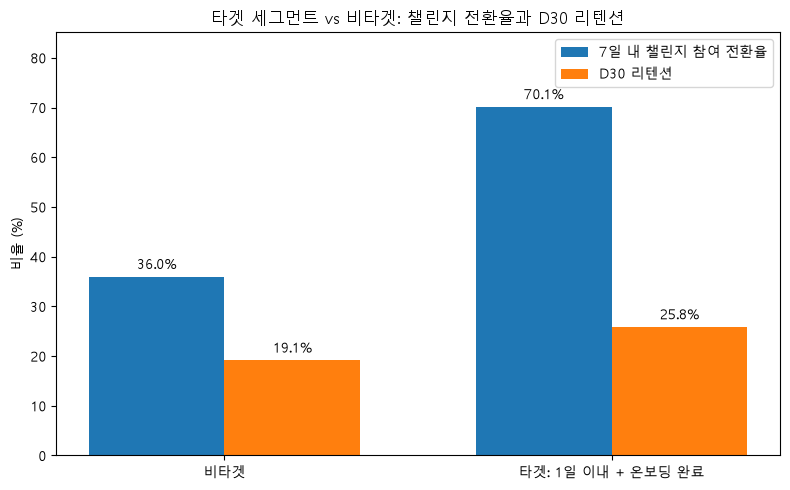

In [58]:
plot_df = target_summary.copy()

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width/2,
    plot_df["challenge_conversion_rate"] * 100,
    width,
    label="7일 내 챌린지 참여 전환율"
)

bars2 = ax.bar(
    x + width/2,
    plot_df["d30_retention_rate"] * 100,
    width,
    label="D30 리텐션"
)

ax.set_title("타겟 세그먼트 vs 비타겟: 챌린지 전환율과 D30 리텐션")
ax.set_ylabel("비율 (%)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["target_group"], rotation=0)
ax.legend()

# 막대 위 수치 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.ylim(0, max(
    plot_df["challenge_conversion_rate"].max(),
    plot_df["d30_retention_rate"].max()
) * 100 + 15)

plt.tight_layout()
plt.show()

In [59]:
timing_plot_df = (
    seg_df
    .groupby("receive_timing_group", observed=False)
    .agg(
        user_count=("user_id", "nunique"),
        conversion_rate=("converted_join_7d", "mean"),
        d30_retention_rate=("d30_retained", "mean")
    )
    .reset_index()
)

timing_order = ["1일 이내", "1~3일", "3~7일", "7일 이후"]

timing_plot_df["receive_timing_group"] = pd.Categorical(
    timing_plot_df["receive_timing_group"],
    categories=timing_order,
    ordered=True
)

timing_plot_df = timing_plot_df.sort_values("receive_timing_group")

display(timing_plot_df)

,receive_timing_group,user_count,conversion_rate,d30_retention_rate
0,1일 이내,1457,0.503089,0.203844
1,1~3일,902,0.317073,0.177384
2,3~7일,431,0.380510,0.245940
3,7일 이후,79,0.544304,0.303797


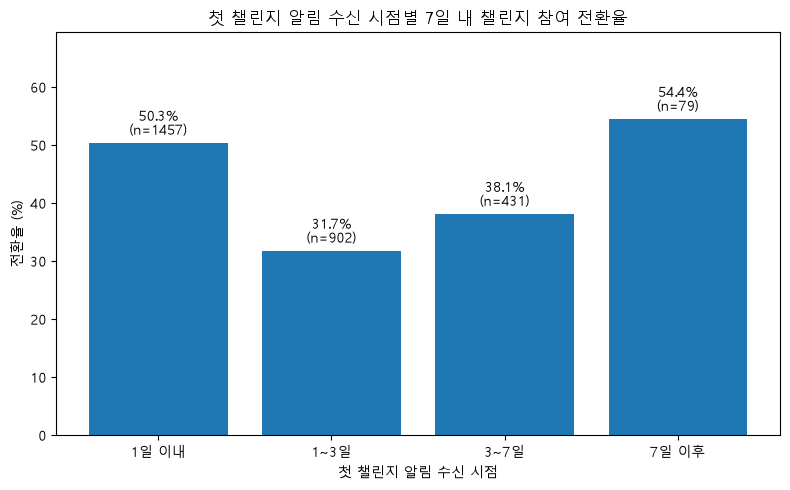

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    timing_plot_df["receive_timing_group"].astype(str),
    timing_plot_df["conversion_rate"] * 100
)

ax.set_title("첫 챌린지 알림 수신 시점별 7일 내 챌린지 참여 전환율")
ax.set_xlabel("첫 챌린지 알림 수신 시점")
ax.set_ylabel("전환율 (%)")

for bar, n in zip(bars, timing_plot_df["user_count"]):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%\n(n={n})",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, timing_plot_df["conversion_rate"].max() * 100 + 15)
plt.tight_layout()
plt.show()

In [61]:
onboarding_plot_df = (
    seg_df
    .groupby(["receive_timing_group", "is_onboarding_completed"], observed=False)
    .agg(
        user_count=("user_id", "nunique"),
        conversion_rate=("converted_join_7d", "mean")
    )
    .reset_index()
)

onboarding_plot_df["receive_timing_group"] = pd.Categorical(
    onboarding_plot_df["receive_timing_group"],
    categories=timing_order,
    ordered=True
)

onboarding_plot_df["onboarding_label"] = np.where(
    onboarding_plot_df["is_onboarding_completed"] == True,
    "온보딩 완료",
    "온보딩 미완료"
)

onboarding_plot_df = onboarding_plot_df.sort_values(
    ["receive_timing_group", "is_onboarding_completed"]
)

display(onboarding_plot_df)

,receive_timing_group,is_onboarding_completed,user_count,conversion_rate,onboarding_label
0,1일 이내,False,888,0.376126,온보딩 미완료
1,1일 이내,True,569,0.701230,온보딩 완료
2,1~3일,False,682,0.326979,온보딩 미완료
3,1~3일,True,220,0.286364,온보딩 완료
4,3~7일,False,324,0.388889,온보딩 미완료
5,3~7일,True,107,0.355140,온보딩 완료
6,7일 이후,False,59,0.525424,온보딩 미완료
7,7일 이후,True,20,0.600000,온보딩 완료


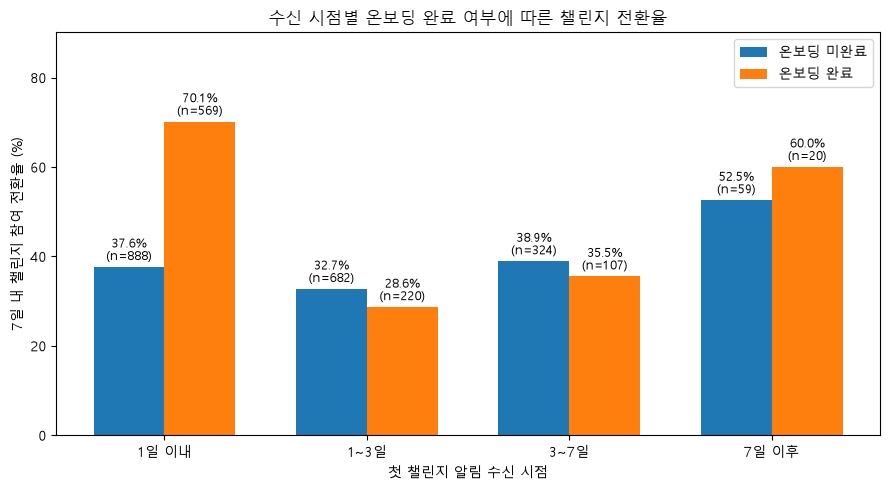

In [62]:
pivot_rate = onboarding_plot_df.pivot(
    index="receive_timing_group",
    columns="onboarding_label",
    values="conversion_rate"
).loc[timing_order]

pivot_count = onboarding_plot_df.pivot(
    index="receive_timing_group",
    columns="onboarding_label",
    values="user_count"
).loc[timing_order]

x = np.arange(len(pivot_rate.index))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width/2,
    pivot_rate["온보딩 미완료"] * 100,
    width,
    label="온보딩 미완료"
)

bars2 = ax.bar(
    x + width/2,
    pivot_rate["온보딩 완료"] * 100,
    width,
    label="온보딩 완료"
)

ax.set_title("수신 시점별 온보딩 완료 여부에 따른 챌린지 전환율")
ax.set_xlabel("첫 챌린지 알림 수신 시점")
ax.set_ylabel("7일 내 챌린지 참여 전환율 (%)")
ax.set_xticks(x)
ax.set_xticklabels(pivot_rate.index.astype(str))
ax.legend()

# 수치 표시
for bars, label in [(bars1, "온보딩 미완료"), (bars2, "온보딩 완료")]:
    for i, bar in enumerate(bars):
        height = bar.get_height()
        n = pivot_count[label].iloc[i]
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}%\n(n={int(n)})",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.ylim(0, max(pivot_rate.max()) * 100 + 20)
plt.tight_layout()
plt.show()